# 单相流计算算例
单相流1D算例, 问题模型，瞬态达西单相流
- 网格数量：$(nx, ny, nz) = (100, 1, 1)$；
- 该网格表示在一个长度方向上的 100 个单元；
- 单元长度：$\Delta x = 1$ m；
- 时间步长：$\Delta t = 0.1$ s；
- 初始压力分布：$P(x, 0) = 10^6$ Pa（均匀分布）；
- 左边界为定压边界：$P_{left}(t) = 10^6$ Pa；
- 右边界为定压边界：$P_{right}(t) = 10^5$ Pa；
- 渗透率：$k = 10^{-12}$ m²；
- 黏度：$\mu = 10^{-3}$ Pa·s；
- 孔隙度：$\phi = 0.2$；
- 源汇项：$q = 0$（无注入或生产）。
## 1. 配置参数
我们这个示例会带你从头开始一步一步了解整个计算流程，后续再使用Simulator 类创建一个对象，将这些过程全部整合。

In [2]:
from reservoirpy import ReservoirSimulator, StructuredMesh, SinglePhaseProperties
from reservoirpy.visualization.plot_3d import create_3d_plotter

# 1. 使用字典配置
config = {
    'mesh': {
        'nx': 10, 'ny': 1, 'nz': 1,
        'dx': 1, 'dy': 1, 'dz': 1
    },
    'physics': {
        'type': 'single_phase',
        'permeability': 100.0,  # mD
        'porosity': 0.2,
        'viscosity': 0.001,     # Pa·s
        'compressibility': 1e-9  # 1/Pa
    },
    'wells': [
        {'location': [0, 0, 0], 'control_type': 'rate', 'value': 0.001},
        {'location': [0, 0, 9], 'control_type': 'bhp', 'value': 1e6}
    ],
    'simulation': {
        'dt': 86400,           # 时间步长(秒)
        'total_time': 31536000, # 总模拟时间(秒)
        'initial_pressure': 30e6 # 初始压力(Pa)
    }
}

## 2. 创建网格

In [3]:
mesh_config = config['mesh']
mesh = StructuredMesh(**mesh_config)
print(mesh)

StructuredMesh(10x1x1, cells=10)


## 3. 创建物理场

In [4]:
physics_config = config['physics']
physics = SinglePhaseProperties(mesh, physics_config)
print( physics)

## 可视化，看一下 permeability

/Users/czl/Developing/reservoirpy/.venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/Users/czl/Developing/reservoirpy/.venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


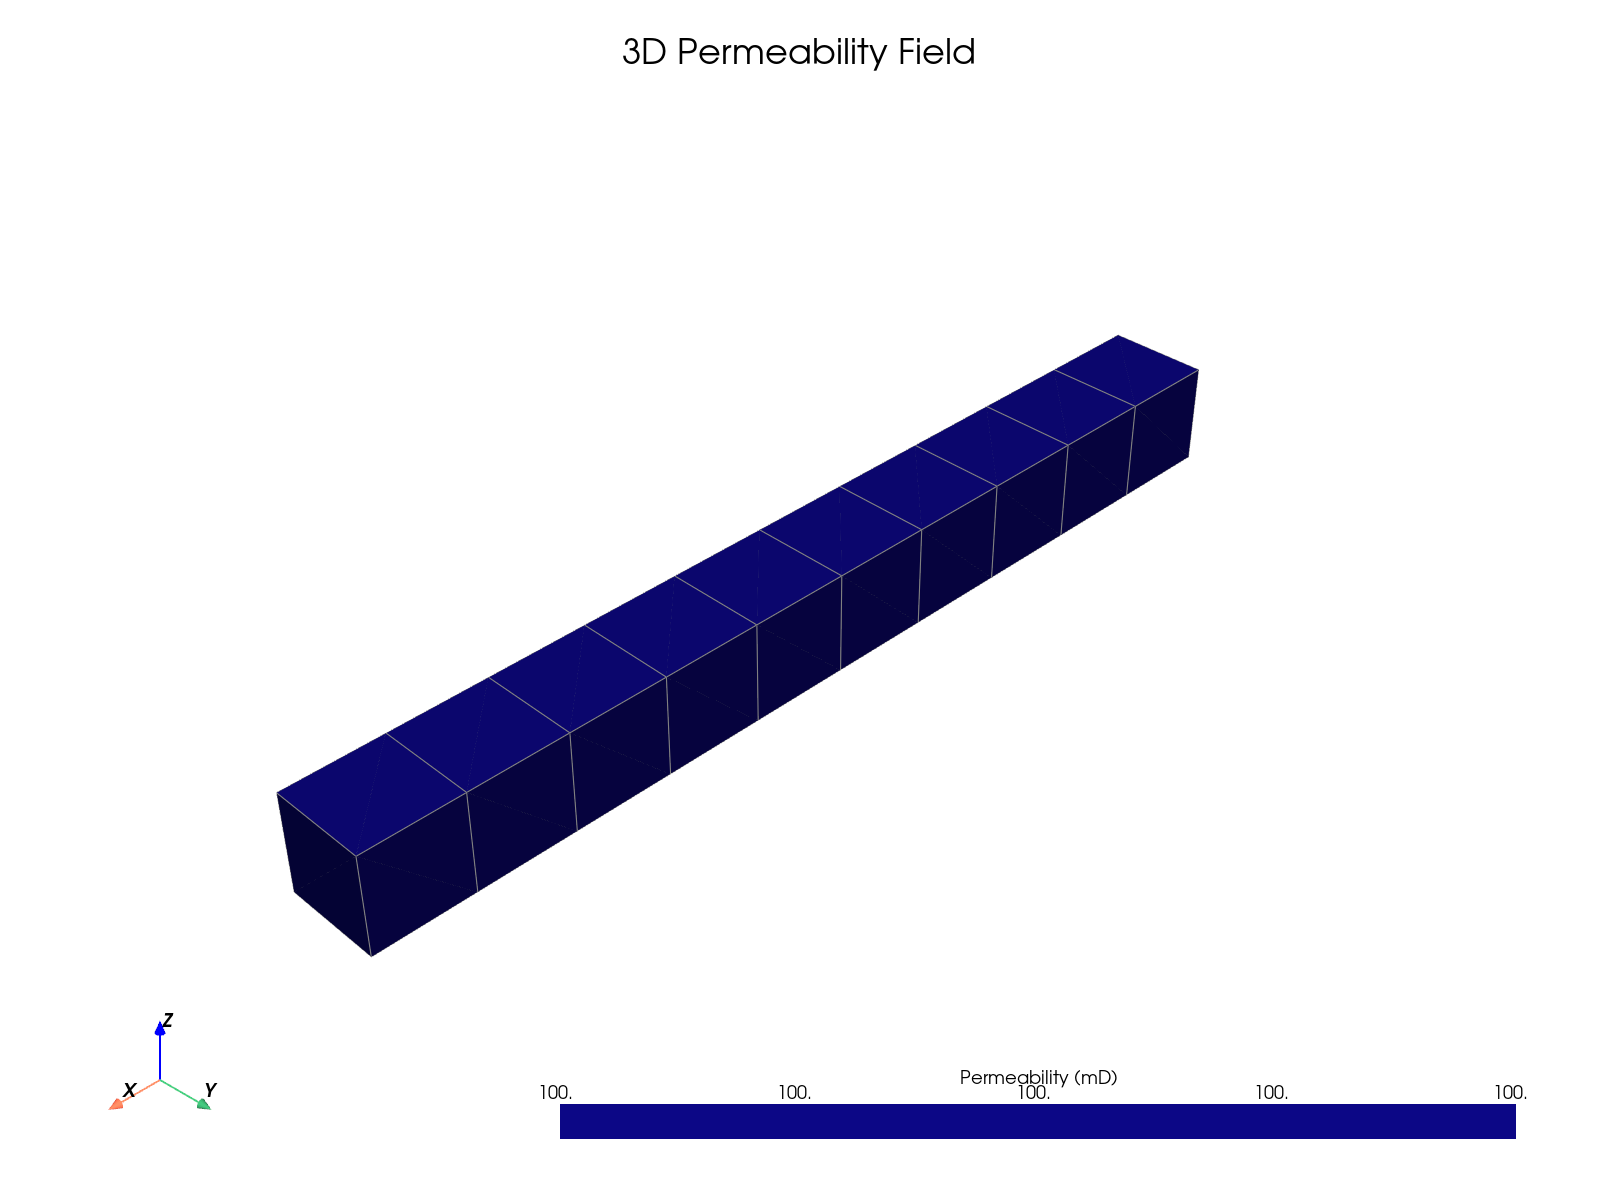

In [9]:

plotter_3d = create_3d_plotter(mesh)
permeability_plotter = plotter_3d.plot_permeability_field_3d(physics.permeability[:, :, :, 0] / physics.mD_to_m2, "3D Permeability Field")
permeability_plotter.show()